In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gamma, lognorm, weibull_min, gaussian_kde, skew, genpareto
from matplotlib.ticker import FuncFormatter


In [2]:
as_all = pd.read_excel('Biome Synbio Top Match EC Comparison.xlsx')
as_all = as_all[as_all['Percentage'] > 0]
as_lost = pd.read_excel('Lost_Functions.xlsx')
as_present = pd.read_excel('Only Present Enzyme Biome Synbio Top Match EC Comparison.xlsx')

#### Entire Biome Functional Space

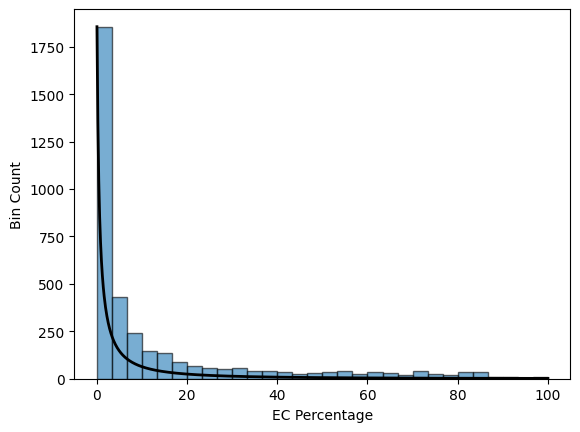

In [26]:

data = np.array(as_all['Percentage'])


counts, bins, _ = plt.hist(data, bins=30, alpha=0.6, edgecolor = 'black')

# Fit a lognormal distribution to the data
shape, loc, scale = lognorm.fit(data, floc=0)

# Generate points on the x-axis
x = np.linspace(min(data), max(data), 1000)

# Calculate the lognormal PDF
pdf = lognorm.pdf(x, shape, loc, scale)

# Scale the PDF to match the histogram
pdf_scaled = pdf * (counts.max() / pdf.max())

# Plot the scaled lognormal PDF
plt.plot(x, pdf_scaled, 'black', lw=2)

plt.xlabel('EC Percentage')
plt.ylabel('Bin Count')
plt.show()


In [4]:
all_array

array([1.00000000e+02, 9.97815004e+01, 9.97815004e+01, ...,
       7.28332119e-02, 7.28332119e-02, 7.28332119e-02])

In [5]:
as_all

,EC Number,Percentage,Name,Synbio Presence/Absence,Top Match Presence/Absence
0,2.7.7.7,100.000000,DNA-directed DNA polymerase.,1,1
1,3.6.4.12,99.781500,DNA helicase.,1,0
2,5.2.1.8,99.781500,peptidylprolyl isomerase.,1,1
3,2.7.13.3,98.980335,histidine kinase.,1,0
4,5.6.2.4,98.397669,DNA 3'-5' helicase.,1,1
...,...,...,...,...,...
3660,2.8.2.5,0.072833,chondroitin 4-sulfotransferase.,0,0
3661,1.1.1.8,0.072833,glycerol-3-phosphate dehydrogenase (NAD(+)).,0,0
3662,1.14.16.4,0.072833,tryptophan 5-monooxygenase.,0,0
3663,4.1.1.76,0.072833,arylmalonate decarboxylase.,0,0


In [6]:
mean = lognorm.mean(shape, loc=loc, scale=scale)
median = lognorm.median(shape, loc=loc, scale=scale)
variance = lognorm.var(shape, loc=loc, scale=scale)
skewness = lognorm.stats(shape, loc=loc, scale=scale, moments='s')  # Skewness
kurtosis = lognorm.stats(shape, loc=loc, scale=scale, moments='k')  # Kurtosis

print(f"Mean: {mean}")
print(f"Variance: {variance}")
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Median: {median}")

Mean: 22.861965080256105
Variance: 28959.975849113413
Skewness: 434.76698204916585
Kurtosis: 10492622.280316086
Median: 3.04399468910012


### Present and Lost Functions

/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Bin Percentage')

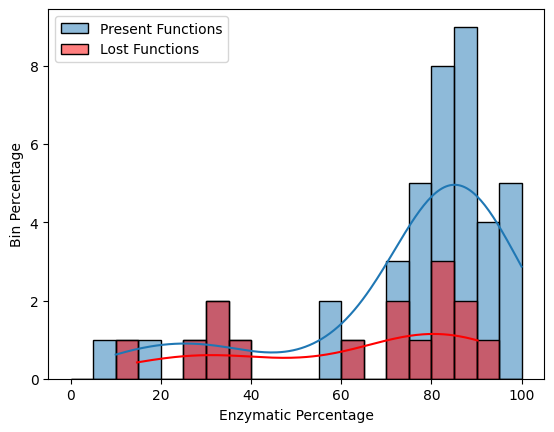

In [7]:


bin_edges = range(0, 101, 5)  # Example: bins from 0 to 100 with a step of 5

sns.histplot(x='Percentage', bins = bin_edges, data = as_present, label = 'Present Functions', kde = True)
sns.histplot(x='Percentage',bins=bin_edges, data = as_lost, color = 'red', label='Lost Functions', kde= True)
plt.legend()
plt.xlabel('Enzymatic Percentage')
plt.ylabel('Bin Percentage')



In [8]:
present_array = np.array(as_present['Percentage'])
lost_array = np.array(as_lost['Percentage'])
shape2, loc2, scale2 = lognorm.fit(present_array, floc = 0)
shape3, loc3, scale3 = lognorm.fit(lost_array, floc = 0)

In [9]:
x2 = np.linspace(min(present_array), max(present_array), 100) #This creates an array of 100 evenly spaced datapoints within the min and max of the given dataset. This then gets fed into the gamma parameters to generate the PDF
x3 = np.linspace(min(lost_array), max(lost_array), 100) 

kde2 = gaussian_kde(present_array)
density2 = kde2(x2)
# wb_fit = weibull_min.fit(present_array)
kde3 = gaussian_kde(lost_array)
density3 = kde3(x3)

# plt.hist(present_array, density=True, alpha = 0.6, edgecolor = 'black')
# plt.plot(x2, weibull_min.pdf(x2, *wb_fit), 'b-', lw=2, label="Weibull fit")

mean = np.sum(x2 * density2) / np.sum(density2)
print('Present Mean Based on Gaussian KDE is:', mean)
variance = np.sum((x2 - mean) ** 2 * density2) / np.sum(density2)
print('Present Variance Based on Gaussian KDE is:', variance)

mean = np.sum(x3 * density3) / np.sum(density3)
print('Lost Mean Based on Gaussian KDE is:', mean)
variance = np.sum((x3 - mean) ** 2 * density3) / np.sum(density3)
print('Lost Variance Based on Gaussian KDE is:', variance)

Present Mean Based on Gaussian KDE is: 72.11922156342904
Present Variance Based on Gaussian KDE is: 503.98750550919624
Lost Mean Based on Gaussian KDE is: 58.74950952234517
Lost Variance Based on Gaussian KDE is: 482.37257604999513


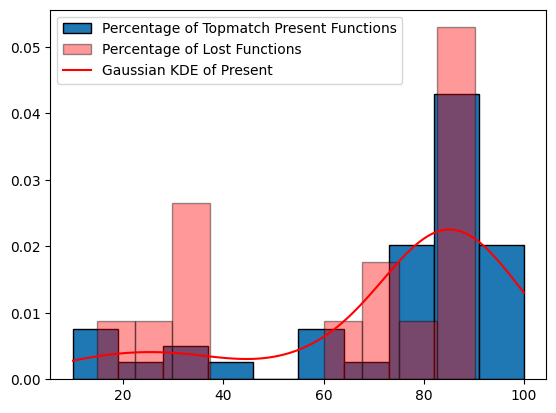

In [10]:
plt.hist(present_array, density=True, edgecolor = 'black', label = 'Percentage of Topmatch Present Functions')
plt.hist(lost_array,color='red', density=True, alpha = 0.4, edgecolor = 'black', label = 'Percentage of Lost Functions')
plt.plot(x2, density2, color = 'red', label = 'Gaussian KDE of Present')
plt.legend()